# Gruppo 2613
- Giacomo Bregolin
- Leonardo Fardin
- Lara Fogarolo
- Francesco Peron

# Point 1

In [1]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras_tuner
import keras

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

2026-03-10 19:02:45.199611: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


In [4]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
from keras import Input

def build_model(hp):
    model = Sequential()
    
    # Input layer (new style)
    model.add(Input(shape=(L,)))
    model.add(Dense(L, activation='relu'))
    
    # Search over dropout rate
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
    activation = hp.Choice("activation", values=["relu", "elu"])
    
    # Inner layers
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Search over learning rate
    learning_rate = hp.Float("learning_rate", min_value=1e-6, max_value=1e-1, sampling="log")
    
    # Search over optimizer
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])
    
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [8]:
# USARE QUESTO SOLO PER CREARE NUOVI DATI
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=2,
    overwrite=True,
    directory="new_trials",
    project_name="my_search"
)

tuner.search(x_train, y_train,
             epochs=100,
             validation_data=(x_valid, y_valid),
             verbose=2)

Trial 50 Complete [00h 01m 59s]
val_accuracy: 0.5455555617809296

Best val_accuracy So Far: 0.9849999845027924
Total elapsed time: 01h 40m 25s


In [ ]:
# Define batch sizes to try
batch_sizes = np.arange(35,55,1)
batch_results = []

for bs in batch_sizes:
    tuner2 = keras_tuner.RandomSearch(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=5,
        overwrite=True,
        directory="my_dir",
        project_name=f"batch_{bs}"
    )
    tuner2.search(x_train, y_train,
                 epochs=75,
                 batch_size=bs,
                 validation_data=(x_valid, y_valid),
                 verbose=2)
    
    best_hp = tuner2.get_best_hyperparameters(1)[0]
    best_acc = tuner2.oracle.get_best_trials(1)[0].score
    batch_results.append({"batch_size": bs, "val_accuracy": best_acc})


batch = pd.DataFrame(batch_results)
print(batch)

In [13]:
# PER RECUPERARE I DATI DEL TRAINING
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=2,
    overwrite=False,
    directory="trials",
    project_name="my_search"
)
trials = tuner.oracle.trials

# Extract dropout rate and val_accuracy for each trial
results = []
for trial in trials.values():
    dropout = trial.hyperparameters.values["dropout_rate"]
    lr = trial.hyperparameters.values["learning_rate"]
    optimizer = trial.hyperparameters.values["optimizer"]
    val_acc = trial.score  # best val_accuracy for that trial
    results.append({"dropout_rate": dropout, "learning_rate": lr,
                    "optimizer": optimizer, "val_accuracy": val_acc})

# Convert to DataFrame
df = pd.DataFrame(results)
print(df)

#batch size diversa
batch_sizes = np.arange(35,55,1)
batch_results = []

for bs in batch_sizes:
    tuner2 = keras_tuner.RandomSearch(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=5,
        overwrite=False,
        directory="my_dir",
        project_name=f"batch_{bs}"
    )
    best_hp = tuner2.get_best_hyperparameters(1)[0]
    best_acc = tuner2.oracle.get_best_trials(1)[0].score
    batch_results.append({"batch_size": bs, "val_accuracy": best_acc})


batch = pd.DataFrame(batch_results)
print(batch)

Reloading Tuner from trials/my_search/tuner0.json
    dropout_rate  learning_rate optimizer  val_accuracy
0            0.1       0.025796     nadam      0.968333
1            0.4       0.000172     nadam      0.692778
2            0.0       0.000029     nadam      0.542778
3            0.0       0.006152     nadam      0.984167
4            0.2       0.000294       sgd      0.545556
5            0.1       0.022805       sgd      0.951389
6            0.1       0.000017   rmsprop      0.548611
7            0.4       0.000010   rmsprop      0.539444
8            0.3       0.000005     nadam      0.555000
9            0.0       0.000010       sgd      0.503611
10           0.0       0.000006   rmsprop      0.548056
11           0.0       0.000002     nadam      0.542222
12           0.0       0.010946   rmsprop      0.977500
13           0.2       0.013871       sgd      0.947500
14           0.4       0.000072      adam      0.552500
15           0.2       0.008703       sgd      0.83138

In [25]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#takes as parameters a list of models, the datasaet
#and the number of k-folds
#gives back the best model index in the list and
#the list of errors for the models
def cross_validation(models, x, y, k=5)->tuple:
    import numpy as np

    #gives back the cost for the given model
    def fit(model, x_train, y_train, x_val, y_val):
        model.fit(x, y)
        y_pred = model.predict(x_val)
        # Return a single float to minimize.
        return np.mean((y_pred - y_val)**2)

    #shuffling the indexes for shuflling the dataset
    #before dividing it in k folds
    idxs = np.arange(y.size)
    np.random.shuffle(idxs)

    #creating folds
    x_fold = []
    y_fold = []

    for i in range(k):
        x_fold.append(x[idxs[i::k]])
        y_fold.append(y[idxs[i::k]])

    #testing the models
    errors = []
    for model in models:
        error = 0
        for i in range(k):
            error += fit(model, x_fold[not i], y_fold[not i],
                                x_fold[i], y_fold[i])
        error.append(error)

    #finding the index of the lowest-cost-model
    errors = np.array(errors)
    best_idx = np.argmin(errors)

    return best_idx, errors

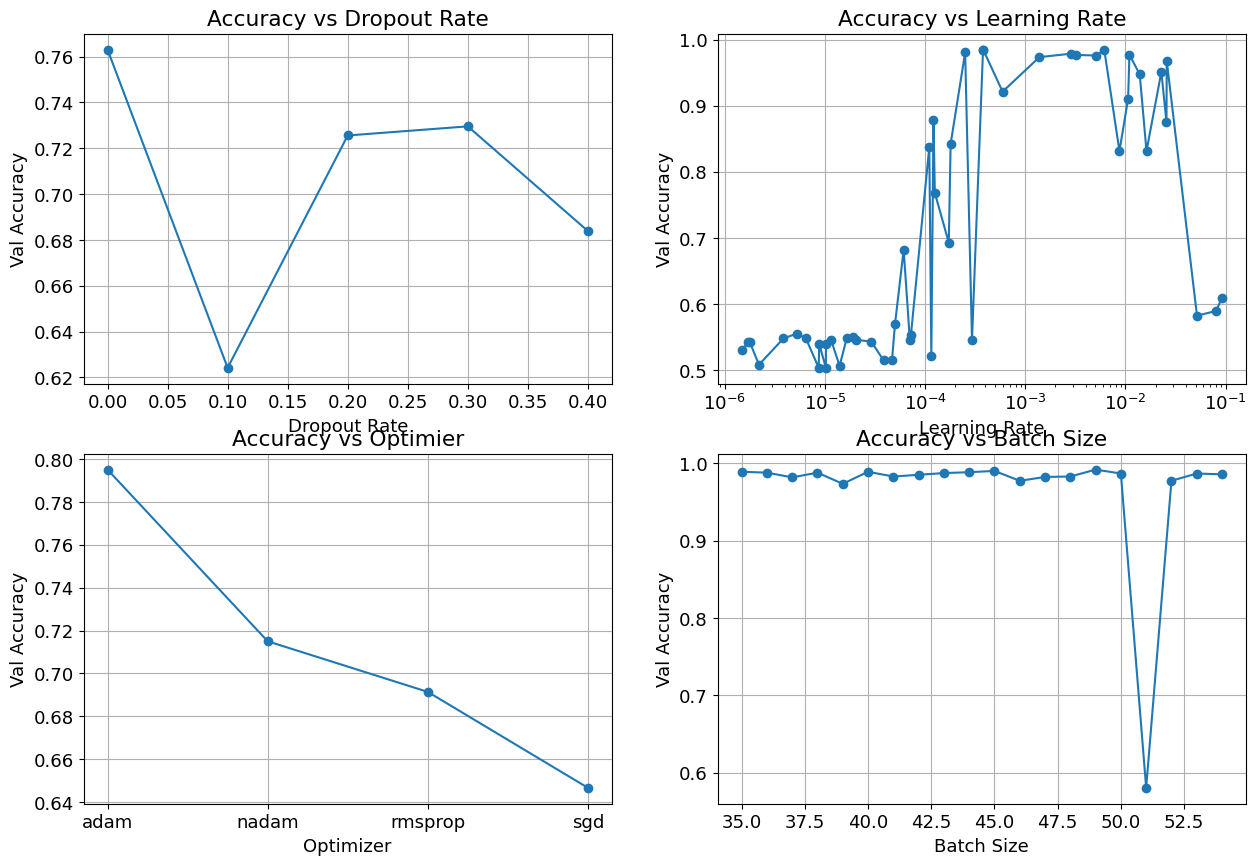

In [24]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(15,10))
# Group by dropout and average val_accuracy
drop = df.groupby("dropout_rate")["val_accuracy"].mean()
lear = df.groupby("learning_rate")["val_accuracy"].mean()
opti = df.groupby("optimizer")["val_accuracy"].mean()


ax[0][0].plot(drop.index, drop.values, marker='o')
ax[0][0].set_xlabel("Dropout Rate")
ax[0][0].set_ylabel("Val Accuracy")
ax[0][0].set_title("Accuracy vs Dropout Rate")
ax[0][0].grid(True)

ax[0][1].plot(lear.index, lear.values, marker='o')
ax[0][1].set_xscale("log")
ax[0][1].set_xlabel("Learning Rate")
ax[0][1].set_ylabel("Val Accuracy")
ax[0][1].set_title("Accuracy vs Learning Rate")
ax[0][1].grid(True)

ax[1][0].plot(opti.index, opti.values, marker='o')
ax[1][0].set_xlabel("Optimizer")
ax[1][0].set_ylabel("Val Accuracy")
ax[1][0].set_title("Accuracy vs Optimier")
ax[1][0].grid(True)

ax[1][1].plot(batch.index, batch.values, marker='o')
ax[1][1].set_xlabel("Batch Size")
ax[1][1].set_ylabel("Val Accuracy")
ax[1][1].set_title("Accuracy vs Batch Size")
ax[1][1].grid(True)
plt.show()

# Point 2

In [ ]:
import random
'''
putting in rid the dataset reduced
keeping 50%, 75%, 90%
'''
rid_x = []
rid_y = []
perc_list = [0.5, 0.75, 0.9]
for perc_keep in perc_list:
    indicies = random.sample(range(0,len(x)), int(len(x)*perc_keep))
    x_rid = x[indicies]
    y_rid = y[indicies]
    rid_x.append(x_rid)
    rid_y.append(y_rid)

In [ ]:
'''
dividing in training validation and test
'''
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])

In [ ]:
'''
generating training datsets with random gaussian noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xg = []
aug_yg = []
for i,p in enumerate(perc_aug):
    g_noise = np.random.normal(0, 0.8, (int(len(x_train)*p),8))
    indicies = random.sample(range(0,len(x_train)), len(g_noise))
    x_train_new = x_train[indicies] + g_noise
    x_train_g_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_g_noise = np.concatenate((y_train, y_train_new))
    aug_xg.append(x_train_g_noise)
    aug_yg.append(y_train_g_noise)
    ax[i].scatter(x_train_g_noise[:,0],x_train_g_noise[:,1],s=6,c=y_train_g_noise)

In [ ]:
'''
generating training datsets with random exponential noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xe = []
aug_ye = []
for i,p in enumerate(perc_aug):
    e_noise = np.tanh(np.sin(g_noise)) 
    indicies = random.sample(range(0,len(x_train)), len(e_noise))
    x_train_new = x_train[indicies] + e_noise
    x_train_e_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_e_noise = np.concatenate((y_train, y_train_new))
    aug_xe.append(x_train_e_noise)
    aug_ye.append(y_train_e_noise)
    ax[i].scatter(x_train_e_noise[:,0],x_train_e_noise[:,1],s=6,c=y_train_e_noise)